# Homework 1

## Group Number: 112
  
### Group Members:
- Duarte Rebelo de São José: ist1103708
- Tiago Ramos da Rocha Neves Caixinha: ist1102437

# Imports and data loading

In [2]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

data = arff.loadarff('column_diagnosis.arff')
df = pd.DataFrame(data[0])
df['class'] = df['class'].str.decode('utf-8')

X = df.drop(columns=['class'])
y = df['class']


# Problem 1

### Identifying the input variable with the highest and lowest discriminative power

In [3]:
f_values, _ = f_classif(X, y)

f_scores = pd.DataFrame({'Feature': X.columns, 'F-Score': f_values})

highest_discriminative_power = f_scores.loc[f_scores['F-Score'].idxmax()]
lowest_discriminative_power = f_scores.loc[f_scores['F-Score'].idxmin()]

print("Feature with Highest Discriminative Power:")
print(highest_discriminative_power)
print("\nFeature with Lowest Discriminative Power:")
print(lowest_discriminative_power)

Feature with Highest Discriminative Power:
Feature    degree_spondylolisthesis
F-Score                  119.122881
Name: 5, dtype: object

Feature with Lowest Discriminative Power:
Feature    pelvic_radius
F-Score        16.866935
Name: 4, dtype: object


### Ploting the class-conditional probability density functions of the two previous variables

C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\dddua\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

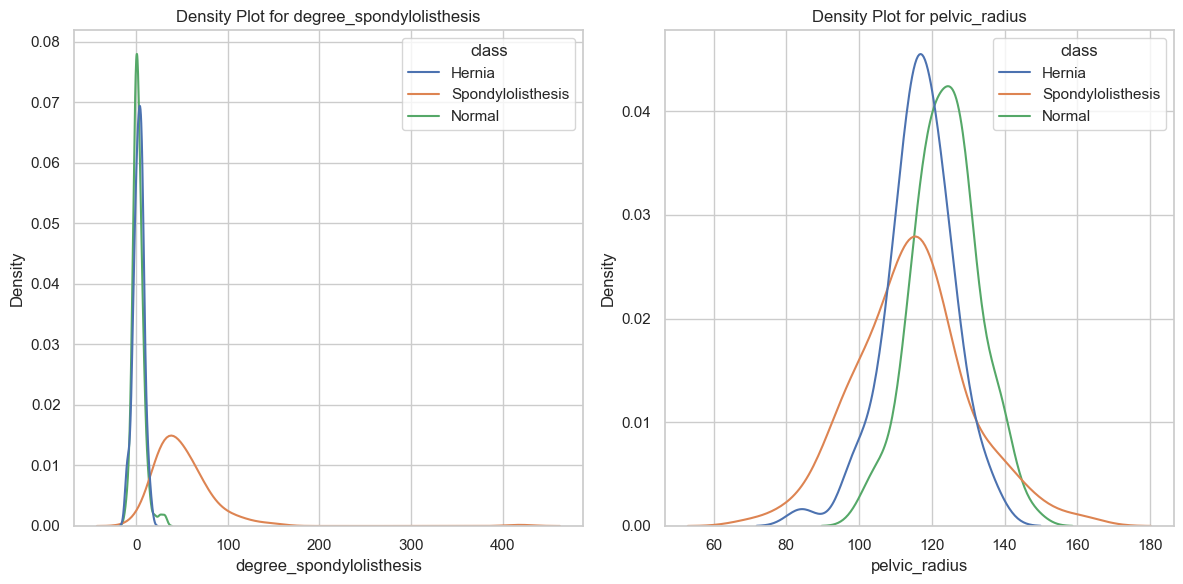

In [4]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x=highest_discriminative_power['Feature'], hue=y, common_norm=False)
plt.title(f'Density Plot for {highest_discriminative_power["Feature"]}')
plt.xlabel(highest_discriminative_power['Feature'])
plt.ylabel('Density')

plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x=lowest_discriminative_power['Feature'], hue=y, common_norm=False)
plt.title(f'Density Plot for {lowest_discriminative_power["Feature"]}')
plt.xlabel(lowest_discriminative_power['Feature'])
plt.ylabel('Density')

plt.tight_layout()
plt.show()

# Problem 2

### Training the decison tree with various depth limits

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

depth_limits = [1, 2, 3, 4, 5, 6, 8, 10]

train_accuracies = []
test_accuracies = []

for depth in depth_limits:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
    clf.fit(X_train, y_train)
    
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

### Plotting the results

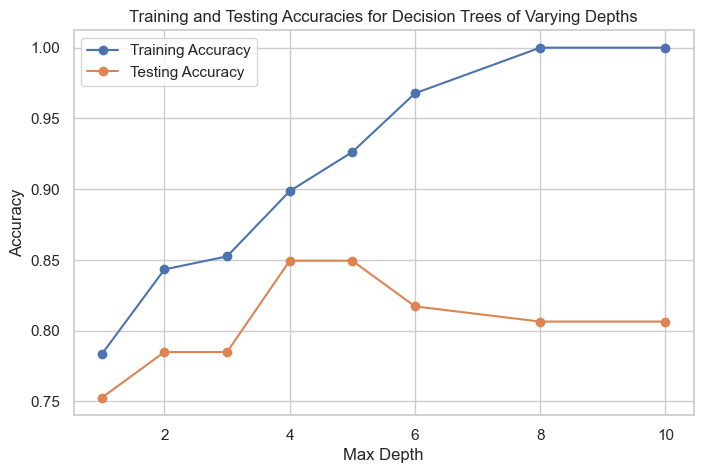

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(depth_limits, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(depth_limits, test_accuracies, label='Testing Accuracy', marker='o')
plt.title('Training and Testing Accuracies for Decision Trees of Varying Depths')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Problem 3

### Commenting on the obtained results

By observing the graphs, we can see that a
As the depth of the decision tree increases, the training accuracy generally improves. This is because deeper trees can capture more compl and fittingex patterns in the training data.For low depth limits (1 to 2) the model is underfitting data due to the low testing and training accuracies. 

However, as the tree depth increases, the testing accu may sstart to decrease after reaching an optimal depth. This is a classic sign of overfitting. The model becomes too specific to the training data and fails to generalize well to unseen data.

The plot helps identify the trade-off between model complexity (depth) and generalization. A depth of63 or 4 appears to be a reasonable choice as it achieves good testing accuracy without overfitting.

# Problem 4

### 4.i) Plotting the decision tree

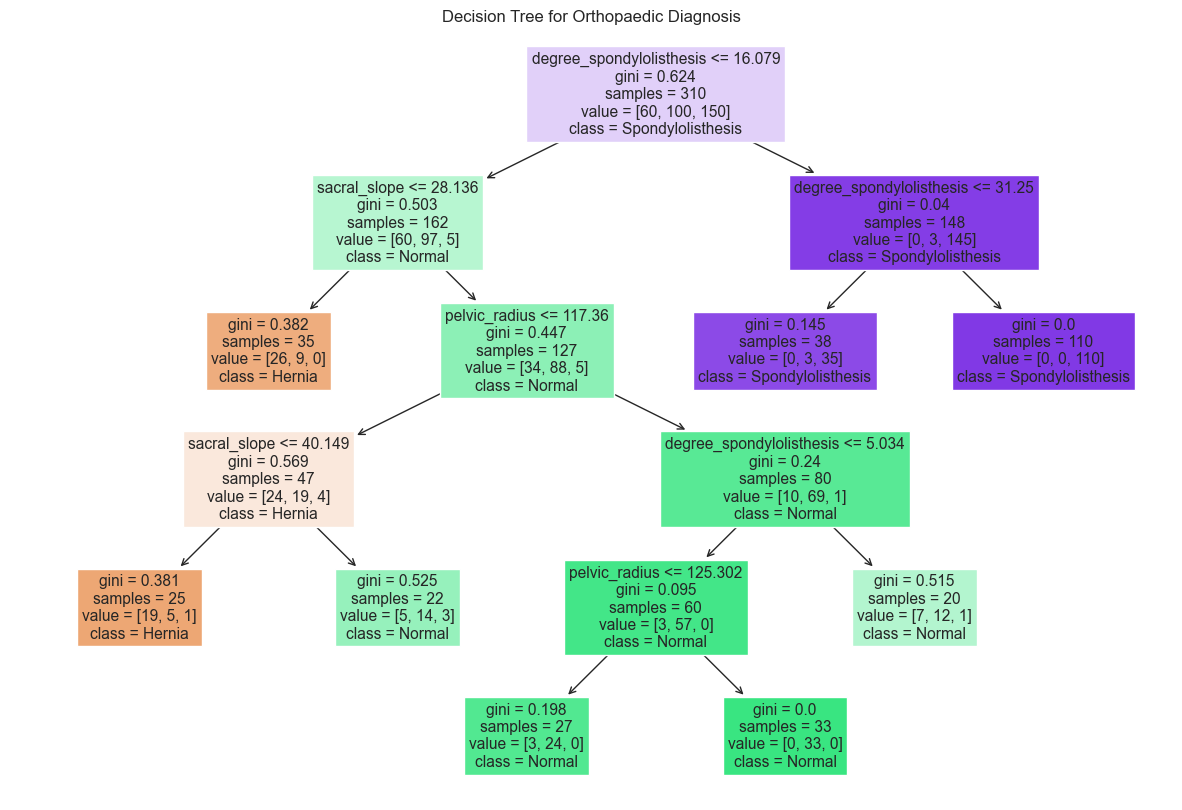

In [7]:
clf_final = DecisionTreeClassifier(random_state=0, min_samples_leaf=20)
clf_final.fit(X, y)

plt.figure(figsize=(15, 10))
plot_tree(clf_final, filled=True, feature_names=X.columns, class_names=clf_final.classes_)
plt.title('Decision Tree for Orthopaedic Diagnosis')
plt.show()

### 4.ii) Characterizing a hernia condition by identifying the hernia-conditional associations

## Normal
- Conditions for a person to be classified as not having Spondylolisthesis nor a hernia:
    - This person has:
        - **Degree spondylolisthesis** less than 16.079,
        - **Sacral slope** greater than 28.136,
        - **Pelvic radius** less than 117.36, and
        - **Sacral slope** greater than 40.149.

    OR

    - This person has:
        - **Degree spondylolisthesis** less than 16.079,
        - **Sacral slope** greater than 28.136, and
        - **Pelvic radius** greater than 117.36.

## Hernia
- Conditions for a person to be classified as having a Hernia:
    - This person has:
        - **Degree spondylolisthesis** less than 16.079 and
        - **Sacral slope** less than 28.136.

    OR

    - This person has:
        - **Degree spondylolisthesis** less than 16.079,
        - **Sacral slope** greater than 28.136,
        - **Pelvic radius** less than 117.36, and
        - **Sacral slope** less than 40.149.

## Spondylolisthesis
- Conditions for a person to be classified as having Spondylolisthesis:
    - This person has:
        - **Degree spondylolnlisthesis** greater than 16.079.
